# Libraries

In [15]:
from functions_victor_project import *
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Charts

### State limit function t = 0

In [20]:
n_latent_samples = 5000
x = np.array([[5, 2]])
y, df = state_limit_function_time(x, n_latent_samples, t=0)
df[0]

,r,s,z1,z2,g
0,5,2,0.987027,0.957957,3.149802
1,5,2,0.993343,0.789537,3.454435
2,5,2,0.970579,1.101502,2.948559
3,5,2,1.008906,0.900510,3.154845
4,5,2,1.043451,1.115970,2.559850
...,...,...,...,...,...
4995,5,2,1.028164,1.002475,2.858089
4996,5,2,1.011863,1.042891,2.855601
4997,5,2,0.968709,1.025044,3.111419
4998,5,2,1.060031,0.997976,2.720892


### State limit function t = 1

In [23]:
n_latent_samples = 5000
x = np.array([[5, 2]])
y, df = state_limit_function_time(x, n_latent_samples, t=1)
ratio_data = df[0]
ratio_data = ratio_data['g'].tolist()

### Ground truth

In [12]:
with open(f'pce_metamodel_1.pkl', 'rb') as f:
    pce_metamodel_up = pickle.load(f)

y_pred = pce_metamodel_up.predict(x)
test_lambda_values = list(y_pred[0])
test_lambda_values

[2.975190931429886, 6.216248258785867, 0.1046084522923329, 0.1559105354042697]

In [14]:
def plot_gld_vs_data(lambdas, n_points=5000, quantile_trim=1e-3, qp_min=1e-8, ylim=None):
    l1, l2, l3, l4 = lambdas

    # Curva da PDF GLD (robusta para evitar explosões numéricas)
    a = float(quantile_trim)
    u = np.linspace(a, 1.0 - a, n_points)
    x = gld_fkml_quantile(u, l1, l2, l3, l4)
    qp = gld_fkml_qprime(u, l2, l3, l4)

    mask = np.isfinite(x) & np.isfinite(qp) & (qp > qp_min)
    x, f = x[mask], (1.0 / qp[mask])

    order = np.argsort(x)
    x, f = x[order], f[order]

    return list(x), list(f)

glam_data, _ = plot_gld_vs_data(test_lambda_values) 

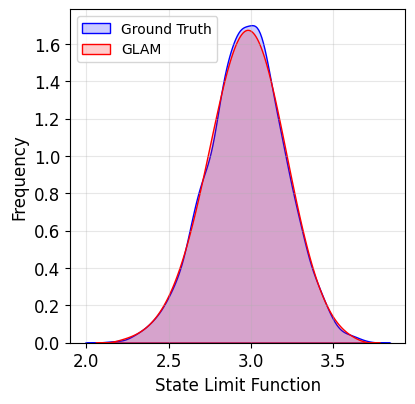

In [24]:
# Figure dimension ans properties
width_cm = 11
height_cm = 11
inches_per_cm = 1 / 2.54
width_in = width_cm * inches_per_cm
height_in = height_cm * inches_per_cm
label_size = 12
axis_size = 12
legend_size = 10
label_color = 'black'

# Plot first KDE with specific color
plt.figure(figsize=(width_in, height_in))

# Ground Truth
sns.kdeplot(data=ratio_data, fill=True, alpha=0.2, color='blue', label='Ground Truth')

# GLAM
sns.kdeplot(data=glam_data, fill=True, alpha=0.2, color='red', label='GLAM')

plt.tick_params(axis='both', which='major', labelsize=axis_size)
plt.xlabel('State Limit Function', fontsize=label_size, color=label_color)
plt.ylabel('Frequency', fontsize=label_size, color=label_color)
plt.grid(alpha=0.3)
plt.legend(fontsize=legend_size, loc='upper left')
plt.show()
# plt.savefig('compare_GLAM_and_GROUNDTRUTH.png', dpi=600)